In [7]:
!python -V

Python 3.9.12


In [8]:
import pandas as pd

In [65]:
import numpy as np

In [9]:
import pickle

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error

In [23]:
df = pd.read_parquet('green_tripdata_2024-01.parquet')
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2024-01-01 00:46:55,2024-01-01 00:58:25,N,1.0,236,239,1.0,1.98,12.8,1.0,0.5,3.61,0.0,NaN,1.0,21.66,1.0,1.0,2.75
1,2,2024-01-01 00:31:42,2024-01-01 00:52:34,N,1.0,65,170,5.0,6.54,30.3,1.0,0.5,7.11,0.0,NaN,1.0,42.66,1.0,1.0,2.75
2,2,2024-01-01 00:30:21,2024-01-01 00:49:23,N,1.0,74,262,1.0,3.08,19.8,1.0,0.5,3.00,0.0,NaN,1.0,28.05,1.0,1.0,2.75
3,1,2024-01-01 00:30:20,2024-01-01 00:42:12,N,1.0,74,116,1.0,2.40,14.2,1.0,1.5,0.00,0.0,NaN,1.0,16.70,2.0,1.0,0.00
4,2,2024-01-01 00:32:38,2024-01-01 00:43:37,N,1.0,74,243,1.0,5.14,22.6,1.0,0.5,6.28,0.0,NaN,1.0,31.38,1.0,1.0,0.00


In [44]:
df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df['duration_t'] = df['duration'].dt.total_seconds()/60
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration,duration_t
0,2,2024-01-01 00:46:55,2024-01-01 00:58:25,N,1.0,236,239,1.0,1.98,12.8,...,3.61,0.0,NaN,1.0,21.66,1.0,1.0,2.75,0 days 00:11:30,11.500000
1,2,2024-01-01 00:31:42,2024-01-01 00:52:34,N,1.0,65,170,5.0,6.54,30.3,...,7.11,0.0,NaN,1.0,42.66,1.0,1.0,2.75,0 days 00:20:52,20.866667
2,2,2024-01-01 00:30:21,2024-01-01 00:49:23,N,1.0,74,262,1.0,3.08,19.8,...,3.00,0.0,NaN,1.0,28.05,1.0,1.0,2.75,0 days 00:19:02,19.033333
3,1,2024-01-01 00:30:20,2024-01-01 00:42:12,N,1.0,74,116,1.0,2.40,14.2,...,0.00,0.0,NaN,1.0,16.70,2.0,1.0,0.00,0 days 00:11:52,11.866667
4,2,2024-01-01 00:32:38,2024-01-01 00:43:37,N,1.0,74,243,1.0,5.14,22.6,...,6.28,0.0,NaN,1.0,31.38,1.0,1.0,0.00,0 days 00:10:59,10.983333


In [48]:
df['duration_t'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    56551.000000
mean        18.171379
std         75.464751
min          0.000000
10%          4.500000
25%          7.250000
50%         11.400000
75%         17.316667
90%         26.000000
99%         59.825000
max       1438.983333
Name: duration_t, dtype: float64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56551 entries, 0 to 56550
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   VendorID               56551 non-null  int32          
 1   lpep_pickup_datetime   56551 non-null  datetime64[ns] 
 2   lpep_dropoff_datetime  56551 non-null  datetime64[ns] 
 3   store_and_fwd_flag     53136 non-null  object         
 4   RatecodeID             53136 non-null  float64        
 5   PULocationID           56551 non-null  int32          
 6   DOLocationID           56551 non-null  int32          
 7   passenger_count        53136 non-null  float64        
 8   trip_distance          56551 non-null  float64        
 9   fare_amount            56551 non-null  float64        
 10  extra                  56551 non-null  float64        
 11  mta_tax                56551 non-null  float64        
 12  tip_amount             56551 non-null  float64

In [52]:
df['lpep_pickup_hour']=df['lpep_pickup_datetime'].dt.hour

In [222]:
df['lpep_pickup_dayofweek']=df['lpep_pickup_datetime'].dt.dayofweek
df['lpep_pickup_weekend']=df['lpep_pickup_dayofweek'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')
df['lpep_pickup_weekend_hour'] = df['lpep_pickup_weekend'].astype(str) + '_' + df['lpep_pickup_hour'].astype(str)

In [55]:
df['PU_DO_LocationID'] = df['PULocationID'].astype(str) + '_' + df['DOLocationID'].astype(str)

In [223]:
df.tail()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,payment_type,trip_type,congestion_surcharge,duration,duration_t,lpep_pickup_hour,PU_DO_LocationID,lpep_pickup_dayofweek,lpep_pickup_weekend,lpep_pickup_weekend_hour
56546,2,2024-01-31 20:46:00,2024-01-31 20:55:00,None,NaN,33,25,NaN,0.00,11.58,...,NaN,NaN,0.0,0 days 00:09:00,9.0,20,33_25,2,weekday,weekday_20
56547,2,2024-01-31 21:06:00,2024-01-31 21:11:00,None,NaN,72,72,NaN,0.49,11.58,...,NaN,NaN,0.0,0 days 00:05:00,5.0,21,72_72,2,weekday,weekday_21
56548,2,2024-01-31 21:36:00,2024-01-31 21:40:00,None,NaN,72,72,NaN,0.52,11.58,...,NaN,NaN,0.0,0 days 00:04:00,4.0,21,72_72,2,weekday,weekday_21
56549,2,2024-01-31 22:45:00,2024-01-31 22:51:00,None,NaN,41,42,NaN,1.17,14.22,...,NaN,NaN,0.0,0 days 00:06:00,6.0,22,41_42,2,weekday,weekday_22
56550,2,2024-01-31 22:28:00,2024-01-31 22:59:00,None,NaN,33,91,NaN,9.27,44.62,...,NaN,NaN,0.0,0 days 00:31:00,31.0,22,33_91,2,weekday,weekday_22


In [58]:
#df = pd.read_parquet('green_tripdata_2024-01.parquet')

#df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
#df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

#df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['lpep_pickup_hour','PU_DO_LocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [152]:
 df['improvement_surcharge'].value_counts()

 1.0    55743
 0.3      447
 0.0      179
-1.0      179
-0.3        3
Name: improvement_surcharge, dtype: int64

In [132]:
 df['congestion_surcharge'].fillna(0, inplace=True)

In [74]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration_t'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

rmse = mean_squared_error(y_train, y_pred, squared=False)
rmse

69.1707842730336

In [73]:
 pd.DataFrame([y_train, y_pred])

,0,1,2,3,4,5,6,7,8,9,...,56541,56542,56543,56544,56545,56546,56547,56548,56549,56550
0,11.500000,20.866667,19.033333,11.866667,10.983333,16.700000,16.216667,11.450000,1.266667,13.383333,...,10.350000,16.000000,8.000000,9.000000,16.000000,9.000000,5.000000,4.00000,6.000000,31.000000
1,11.114968,23.305037,13.736470,31.748547,16.597372,16.797509,21.702315,10.565788,8.324187,16.328372,...,16.502407,8.877966,4.019865,6.758739,15.689902,7.338131,3.163652,3.16365,8.122375,30.352993


/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


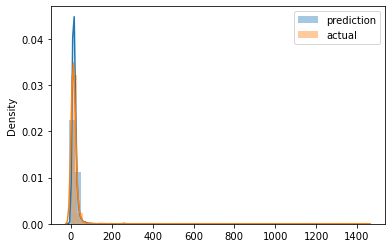

In [70]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [210]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df['duration_t'] = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration_t >= 0) & (df.duration_t <= 60)]
    
    df = df[df.trip_type.notna()]
    
    df['lpep_pickup_hour']=df['lpep_pickup_datetime'].dt.hour
    
    df['lpep_pickup_dayofweek']=df['lpep_pickup_datetime'].dt.dayofweek
    
    df['lpep_pickup_weekend']=df['lpep_pickup_dayofweek'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')
    
    df['lpep_pickup_weekend_hour'] = df['lpep_pickup_weekend'].astype(str) + '_' + df['lpep_pickup_hour'].astype(str)
    
    df['PU_DO_LocationID'] = df['PULocationID'].astype(str) + '_' + df['DOLocationID'].astype(str)

    categorical = ['lpep_pickup_hour','PU_DO_LocationID']
    df[categorical] = df[categorical].astype(str)
    
    df['congestion_surcharge'].fillna(0, inplace=True)
    df['improvement_surcharge'].fillna(0, inplace=True)
    
    return df

In [211]:
df_train = read_dataframe('green_tripdata_2024-01.parquet')
df_val = read_dataframe('green_tripdata_2024-02.parquet')

In [212]:
len(df_train), len(df_val)

(52656, 50124)

In [228]:
df_train.duration_t.describe()

count    52656.000000
mean        12.976168
std          8.773712
min          0.000000
25%          7.100000
50%         11.100000
75%         16.550000
max         59.983333
Name: duration_t, dtype: float64

In [213]:
df_train.tail()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,payment_type,trip_type,congestion_surcharge,duration,duration_t,lpep_pickup_hour,lpep_pickup_dayofweek,lpep_pickup_weekend,lpep_pickup_weekend_hour,PU_DO_LocationID
53131,2,2024-01-31 23:48:18,2024-02-01 00:01:52,N,1.0,130,218,2.0,3.28,16.3,...,1.0,1.0,0.0,0 days 00:13:34,13.566667,23,2,weekday,weekday_23,130_218
53132,2,2024-01-31 23:14:12,2024-01-31 23:25:41,N,1.0,130,219,1.0,4.20,19.8,...,1.0,1.0,0.0,0 days 00:11:29,11.483333,23,2,weekday,weekday_23,130_219
53133,2,2024-01-31 23:19:14,2024-01-31 23:19:27,N,5.0,181,181,2.0,0.00,74.0,...,1.0,2.0,0.0,0 days 00:00:13,0.216667,23,2,weekday,weekday_23,181_181
53134,2,2024-01-31 23:22:53,2024-01-31 23:31:25,N,1.0,74,116,1.0,2.20,12.1,...,1.0,1.0,0.0,0 days 00:08:32,8.533333,23,2,weekday,weekday_23,74_116
53135,2,2024-01-31 23:22:45,2024-01-31 23:24:51,N,5.0,41,41,1.0,0.42,10.0,...,2.0,2.0,0.0,0 days 00:02:06,2.100000,23,2,weekday,weekday_23,41_41


In [215]:
df_train.lpep_pickup_weekend_hour.value_counts()

weekday_17    3513
weekday_18    3382
weekday_16    3286
weekday_15    3019
weekday_19    2634
weekday_14    2549
weekday_9     2296
weekday_13    2284
weekday_10    2202
weekday_8     2192
weekday_11    2180
weekday_12    2159
weekday_20    1932
weekday_7     1906
weekday_21    1400
weekday_22    1142
weekday_23     861
weekend_15     836
weekend_17     824
weekend_18     818
weekend_16     808
weekend_14     772
weekend_19     758
weekday_6      698
weekend_13     696
weekend_12     593
weekend_11     580
weekday_0      577
weekend_20     568
weekend_21     481
weekend_10     476
weekend_0      393
weekend_9      391
weekend_22     383
weekday_1      369
weekend_23     352
weekend_1      348
weekend_2      272
weekend_8      254
weekday_2      231
weekend_3      226
weekday_5      214
weekend_7      187
weekday_3      156
weekend_4      141
weekday_4      140
weekend_6      109
weekend_5       68
Name: lpep_pickup_weekend_hour, dtype: int64

In [216]:
categorical = ['PU_DO_LocationID','lpep_pickup_weekend_hour', 'trip_type', 'congestion_surcharge', 'improvement_surcharge']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [217]:
target = 'duration_t'
y_train = df_train[target].values
y_val = df_val[target].values

In [225]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred, squared=False)

5.68502679101457

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


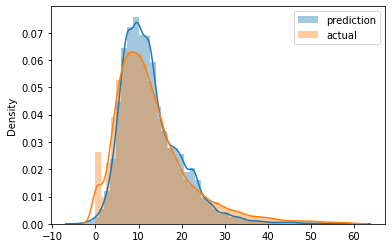

In [226]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_val, label='actual')

plt.legend()

In [221]:
with open('lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [219]:
lr = Ridge(alpha=0.00001)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred, squared=False)

5.695940847452012

/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/home/codespace/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


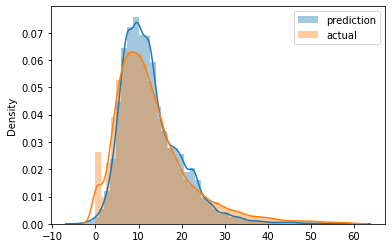

In [224]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_val, label='actual')

plt.legend()